# durations/ep260119a_exploration

迁移自 / Migrated from `test/test_txx_ep260119a.ipynb`.

状态 / Status: **legacy_analysis**. 保留原报错和探索内容；部分单元依赖缺失变量 / Preserves errors/exploration; some cells use undefined variables

历史输出保留，不代表迁移后重新验证；原报错数量 / Preserved historical errors: 1.
Historical outputs are retained and are not evidence of a new successful run.

输入路径在下一单元集中配置；原始数据留在原位置。
Input roots are configured below; original data remain in place.


In [ ]:
# 从仓库定位输入，允许通过环境变量覆盖；不移动原始数据。
# Locate repository inputs with environment overrides; original data stay in place.
from pathlib import Path
from datetime import datetime, timezone
import os
_anchor = Path(__file__).resolve().parent if '__file__' in globals() else Path.cwd()
REPO_ROOT = next((p for p in (_anchor, *_anchor.parents)
                  if (p/'packages/jinwu').is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError('请从 JinWu 仓库内运行 / Run from within the JinWu checkout')
RESEARCH_ROOT = Path(os.environ.get('JINWU_EXAMPLE_RESEARCH_ROOT', REPO_ROOT.parent))
TEST_DATA_ROOT = Path(os.environ.get('JINWU_EXAMPLE_TEST_ROOT', REPO_ROOT/'test'))
DOWNLOAD_ROOT = Path(os.environ.get('JINWU_EXAMPLE_DOWNLOAD_ROOT', Path.home()/'下载'))
# 图件写入独立运行目录，不覆盖研究目录中的历史图。
# Write figures into a unique run directory, preserving historical research plots.
OUTPUT_DIR = Path(os.environ.get('JINWU_EXAMPLE_OUTPUT_ROOT', REPO_ROOT/'examples/_outputs')) / datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)


# T100/T90/T50 测试（EP260119a）

该 notebook 使用以下两个 EVT 文件进行测试：
- `/home/xinxiang/research/EP260119a/ep11900560514wxtCMOS48l23v2_20260209_163436/EP260119a_src.evt`
- `/home/xinxiang/research/EP260119a/ep11900560514wxtCMOS48l23v2_20260209_163436/EP260119a_bkg.evt`

流程：读取事件 -> 1s 分箱 -> 估计 alpha（源/背景面积比）-> 调用 `jinwu.core.ops.txx` 计算 T100/T90/T50。

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

REPO = Path(str(RESEARCH_ROOT))
SRC_EVT = REPO / 'EP260119a/ep11900560514wxtCMOS48l23v2/wxtt90/EP260119a_src.evt'
BKG_EVT = REPO / 'EP260119a/ep11900560514wxtCMOS48l23v2/wxtt90/EP260119a_bkg.evt'

assert SRC_EVT.exists(), f'缺少文件: {SRC_EVT}'
assert BKG_EVT.exists(), f'缺少文件: {BKG_EVT}'

JINWU_SRC = REPO_ROOT / 'packages' / 'jinwu' / 'src'
if str(JINWU_SRC) not in sys.path:
    sys.path.insert(0, str(JINWU_SRC))

print('SRC_EVT =', SRC_EVT)
print('BKG_EVT =', BKG_EVT)
print('JINWU_SRC =', JINWU_SRC)

SRC_EVT = /home/xinxiang/research/EP260119a/ep11900560514wxtCMOS48l23v2/wxtt90/EP260119a_src.evt
BKG_EVT = /home/xinxiang/research/EP260119a/ep11900560514wxtCMOS48l23v2/wxtt90/EP260119a_bkg.evt
JINWU_SRC = /home/xinxiang/research/jinwu/src


## Timescale 类测试

下面测试新的 `timescale` 类：
- 方式 A：直接用事件文件路径构造
- 方式 B：由 `EventData.timescale(...)` 构造
- 并与 `ops.txx` 结果做数值对比（T90/T50）

## 最简单教程（直接画图）

目标：初始化后直接 `plot`，不手动调用 `compute`。

步骤：
1. 用路径创建 `timescale` 对象
2. 在 `plot` 里传 `binsize`
3. 从 `plot` 返回的 `res_simple` 读取 T100/T90/T50

In [2]:
0.10708278549354464


0.10708278549354464

Timescale summary
timezero = 2026-01-19T00:13:08.825
T100: 141.0 s  [0.0, 141.0] s rel. timezero
T90: 126.9 (-26.7/+3.5) s  [7.0, 133.9] s rel. timezero
T50: 70.5 (-23.1/+4.9) s  [35.2, 105.7] s rel. timezero


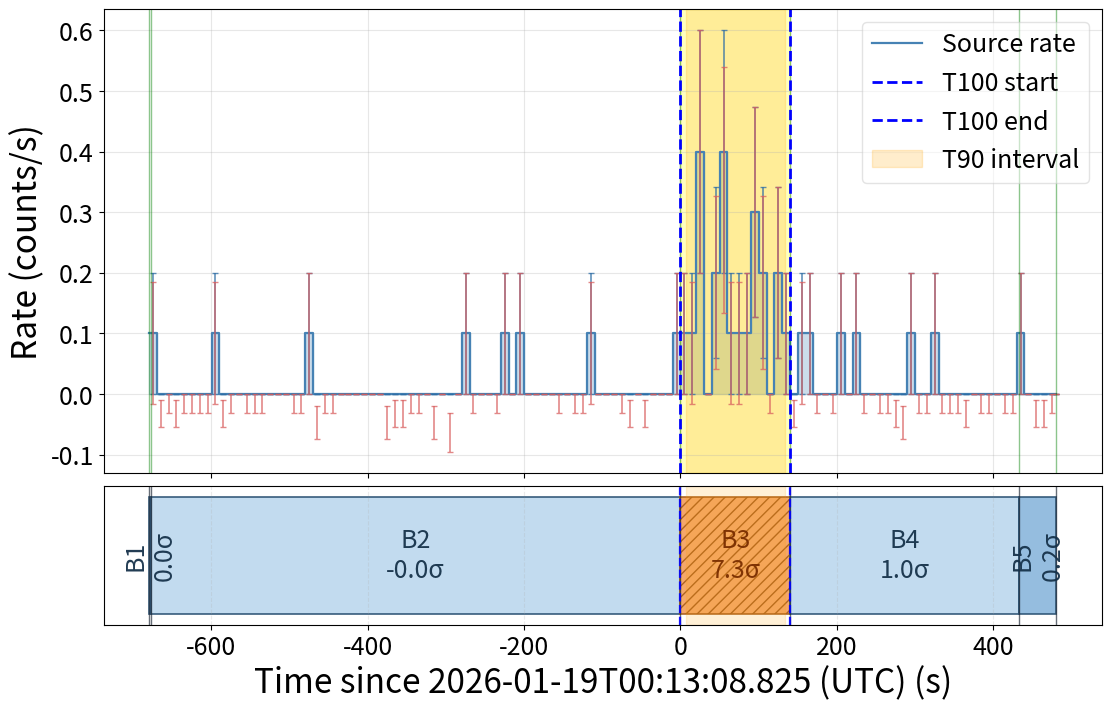

method = aanda_2021_sec5_4
evt_binsize = 10.0
Top legend = ['Source rate', 'T100 start', 'T100 end', 'T90 interval']
修正后的面积因子alpha_scaled= 0.1583073864756784


In [3]:
# 最简单可运行示例：初始化后直接 plot（不手动 compute）
import importlib
import jinwu.core.data as data_mod
import jinwu.core.plot as plot_mod
from jinwu.core.time import Time

data_mod = importlib.reload(data_mod)
plot_mod = importlib.reload(plot_mod)
alpha_scaled = 0.1583073864756784
timezero = Time(190944788.8249, format='ep')
ts_simple = data_mod.timescale(SRC_EVT, background=BKG_EVT, timezero=timezero, alpha = alpha_scaled)
fig_simple, axes_simple, res_simple = ts_simple.plot(
    srcname="EP260119a",
    binsize=10.0,
    forpaper=True,
    # out="EP260119a_txx_forpaper.png",
)
plt.show()

print('method =', res_simple.get('method'))
print('evt_binsize =', res_simple.get('evt_binsize'))
print('Top legend =', [t.get_text() for t in axes_simple[0].get_legend().get_texts()])
# print('Mid legend =', [t.get_text() for t in axes_simple[1].get_legend().get_texts()])
print('修正后的面积因子alpha_scaled=', alpha_scaled)

In [4]:
ts_simple.t90

{'value': 126.8550900220871,
 'err_low': 26.719003025703174,
 'err_high': 3.4859843597888944,
 'err': {'low': 26.719003025703174, 'high': 3.4859843597888944}}

In [5]:
ts_simple.t100_tstart

190944788.8249

In [6]:
ts_simple.t100_tstop

190944929.775

In [7]:
[ts_simple.t90_tstart- ts_simple.t100_tstart, ts_simple.t90_tstop- ts_simple.t100_tstart] 

[7.0475049912929535, 133.90259501338005]

In [18]:
Time(ts_simple.t90_tstart, format='ep').utc.isot, Time(ts_simple.t90_tstop, format='ep').utc.isot

('2026-01-19T00:13:15.872', '2026-01-19T00:15:22.727')

In [20]:
Time(ts_simple.t100_tstart, format='ep').utc.isot, Time(ts_simple.t100_tstop, format='ep').utc.isot

('2026-01-19T00:13:08.825', '2026-01-19T00:15:29.775')

In [8]:
np.array([190944795.872405, 190944922.727495]) - 190944109.153

array([686.719405  , 813.57449502])

In [9]:
ts_simple.t100_tstart, ts_simple.t100_tstop

(190944788.8249, 190944929.775)

In [10]:
np.array([190944788.8249, 190944929.775]) - 190944109.153

array([679.6719    , 820.62200001])

"190944795.872405, 190944922.727495"

Timescale summary
timezero = 2026-01-19T00:13:02.653
T100: 141.0 s  [6.2, 147.1] s rel. timezero
T90: 126.9 (-26.8/+3.3) s  [13.2, 140.1] s rel. timezero
T50: 70.5 (-23.8/+2.8) s  [41.4, 111.9] s rel. timezero


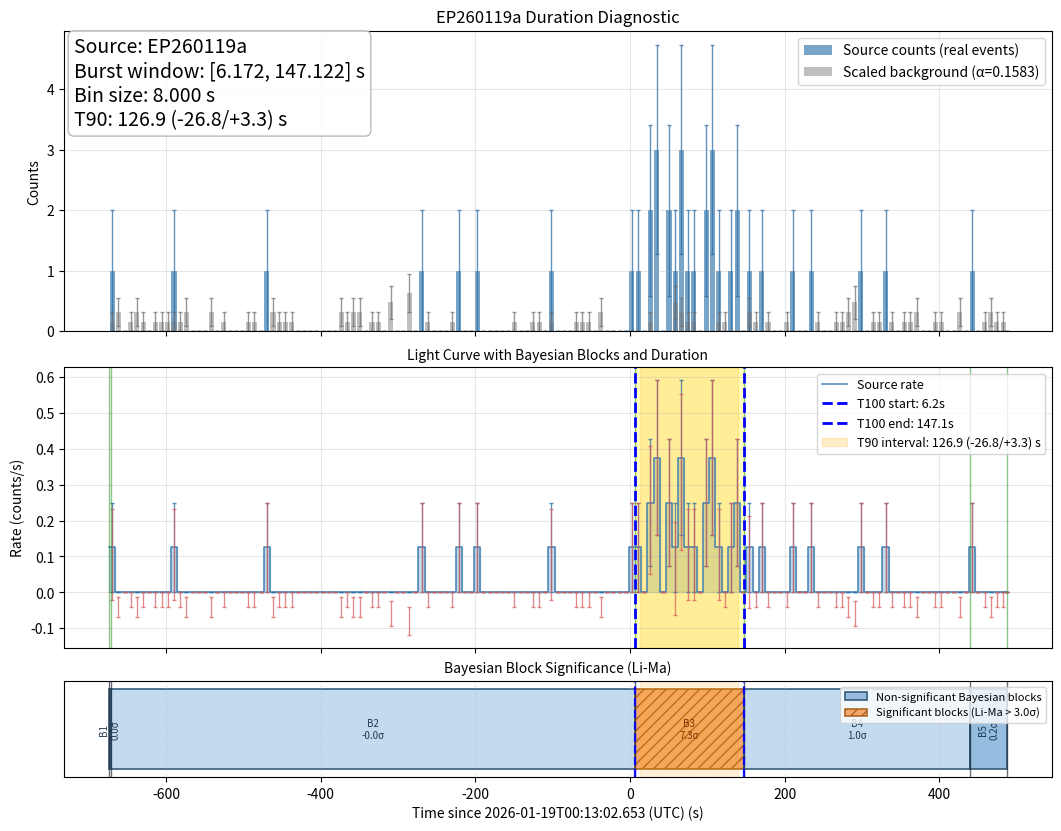

In [11]:
import importlib
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# 重新加载模块
import jinwu.core.data as data_mod
data_mod = importlib.reload(data_mod)

# 使用已有的光变数据
timezero = Time('2026-01-19T00:13:02.653', format='isot', scale='utc')
ts = data_mod.timescale(SRC_EVT, background=BKG_EVT, timezero=timezero, alpha=alpha_scaled)
fig, axes, res = ts.plot(srcname='EP260119a', binsize=8.0)



In [12]:
from jinwu.core.io import readfits


src = readfits(SRC_EVT)
bkg = readfits(BKG_EVT)

In [13]:
res['bb_edges_time'][0]

np.float64(190944109.153)

In [14]:
src.timezero

190944111.7499

In [15]:
res['t100_tstart']

190944788.8249

In [16]:
# 直接从时间序列重新计算
from numpy import histogram

# 定义分箱边界（与绘图一致）
binsize = 8.0
t_start = res['bb_edges_time'][0]  # 或自己指定
t_end = res['bb_edges_time'][-1]
bins = np.arange(t_start, t_end + binsize, binsize)

# 从事件文件重新分箱
times_centers = (bins[:-1] + bins[1:]) / 2
src_hist, _ = np.histogram(src.time+src.timezero, bins=bins)
bkg_hist, _ = np.histogram(bkg.time+bkg.timezero, bins=bins)
net_counts = src_hist - bkg_hist/12

# 然后找峰
peaks, _ = find_peaks(net_counts, height=0.5, distance=3)
peaks+res['t100_tstart']-timezero.ep

array([ 16.1719,  31.1719,  56.1719,  62.1719,  65.1719,  77.1719,
        90.1719,  94.1719,  98.1719, 103.1719, 107.1719, 111.1719,
       116.1719, 119.1719, 127.1719, 131.1719, 145.1719])

In [17]:
lc.plot()

NameError: name 'lc' is not defined

<class 'jinwu.core.data.LightcurveData'>
has time: True
has value: True
has rate: True
timezero: 190944111.7499
npts: 7
tmin/tmax: (354.0, 969.5)


检测到 18 个峰：
  峰1：时间=80.0s，强度=1.00
  峰2：时间=195.0s，强度=1.00
  峰3：时间=400.0s，强度=1.00
  峰4：时间=450.0s，强度=1.00
  峰5：时间=470.0s，强度=1.00
  峰6：时间=680.0s，强度=1.00
  峰7：时间=700.0s，强度=2.00
  峰8：时间=720.0s，强度=2.00
  峰9：时间=735.0s，强度=2.00
  峰10：时间=750.0s，强度=1.00
  峰11：时间=770.0s，强度=2.00
  峰12：时间=795.0s，强度=1.00
  峰13：时间=825.0s，强度=1.00
  峰14：时间=840.0s，强度=1.00
  峰15：时间=880.0s，强度=1.00
  峰16：时间=900.0s，强度=1.00
  峰17：时间=970.0s，强度=1.00
  峰18：时间=1000.0s，强度=1.00

拟合结果：
  峰1：中心=80.00s，宽度=1.69s，幅度=0.975
  峰2：中心=195.00s，宽度=1.69s，幅度=0.975
  峰3：中心=400.00s，宽度=1.69s，幅度=0.975
  峰4：中心=450.00s，宽度=1.69s，幅度=0.975
  峰5：中心=470.00s，宽度=1.69s，幅度=0.975
  峰6：中心=680.00s，宽度=1.69s，幅度=0.975
  峰7：中心=702.50s，宽度=3.29s，幅度=9.814
  峰8：中心=722.24s，宽度=3.20s，幅度=7.706
  峰9：中心=737.24s，宽度=3.20s，幅度=7.713
  峰10：中心=749.83s，宽度=1.65s，幅度=0.982
  峰11：中心=773.00s，宽度=18.34s，幅度=1.555
  峰12：中心=795.03s，宽度=1.64s，幅度=0.947
  峰13：中心=825.00s，宽度=1.69s，幅度=0.975
  峰14：中心=840.00s，宽度=1.69s，幅度=0.975
  峰15：中心=880.00s，宽度=1.69s，幅度=0.975
  峰16：中心=900.00s，宽度=1.69s，幅度=0.975
  峰17：中心

检测到 18 个峰：
  峰1：时间=80.0s，强度=1.00
  峰2：时间=195.0s，强度=1.00
  峰3：时间=400.0s，强度=1.00
  峰4：时间=450.0s，强度=1.00
  峰5：时间=470.0s，强度=1.00
  峰6：时间=680.0s，强度=1.00
  峰7：时间=700.0s，强度=2.00
  峰8：时间=720.0s，强度=2.00
  峰9：时间=735.0s，强度=2.00
  峰10：时间=750.0s，强度=1.00
  峰11：时间=770.0s，强度=2.00
  峰12：时间=795.0s，强度=1.00
  峰13：时间=825.0s，强度=1.00
  峰14：时间=840.0s，强度=1.00
  峰15：时间=880.0s，强度=1.00
  峰16：时间=900.0s，强度=1.00
  峰17：时间=970.0s，强度=1.00
  峰18：时间=1000.0s，强度=1.00

拟合结果：
  峰1：中心=80.00s，宽度=1.69s，幅度=0.975
  峰2：中心=195.00s，宽度=1.69s，幅度=0.975
  峰3：中心=400.00s，宽度=1.69s，幅度=0.975
  峰4：中心=450.00s，宽度=1.69s，幅度=0.975
  峰5：中心=470.00s，宽度=1.69s，幅度=0.975
  峰6：中心=680.00s，宽度=1.69s，幅度=0.975
  峰7：中心=702.50s，宽度=3.29s，幅度=9.814
  峰8：中心=722.24s，宽度=3.20s，幅度=7.706
  峰9：中心=737.24s，宽度=3.20s，幅度=7.713
  峰10：中心=749.83s，宽度=1.65s，幅度=0.982
  峰11：中心=773.00s，宽度=18.34s，幅度=1.555
  峰12：中心=795.03s，宽度=1.64s，幅度=0.947
  峰13：中心=825.00s，宽度=1.69s，幅度=0.975
  峰14：中心=840.00s，宽度=1.69s，幅度=0.975
  峰15：中心=880.00s，宽度=1.69s，幅度=0.975
  峰16：中心=900.00s，宽度=1.69s，幅度=0.975
  峰17：中心

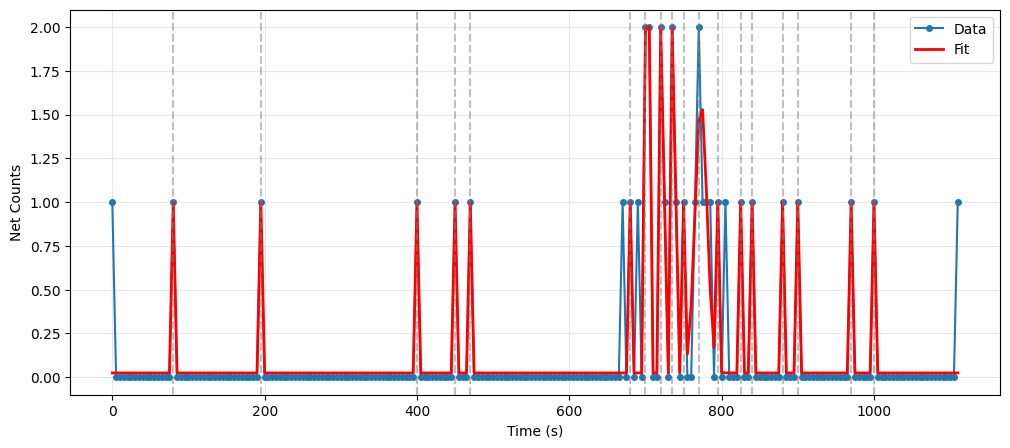

In [ ]:
# 提取光变数据
times = srclc.time
src_counts = srclc.value

net_counts = src_counts  # 净信号

# 找到峰值位置（自动检测）
peaks, props = find_peaks(net_counts, height=0.5, distance=3)

print(f"检测到 {len(peaks)} 个峰：")
for i, peak in enumerate(peaks):
    print(f"  峰{i+1}：时间={times[peak]:.1f}s，强度={net_counts[peak]:.2f}")

# 多高斯拟合
def multi_gaussian(x, *params):
    offset = params[-1]
    result = np.ones_like(x, dtype=float) * offset
    n_peaks = (len(params) - 1) // 3
    for i in range(n_peaks):
        amp, mu, sigma = params[3*i:3*i+3]
        result += amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    return result

# 初值猜测
initial_guess = []
for peak in peaks:
    initial_guess.extend([
        net_counts[peak],        # 幅度
        times[peak],             # 中心时间
        2.0                      # 宽度（秒）
    ])
initial_guess.append(0.1)  # 偏移

# 执行拟合
try:
    popt, pcov = curve_fit(
        multi_gaussian, times, net_counts, 
        p0=initial_guess,
        maxfev=5000
    )
    
    # 结果
    print("\n拟合结果：")
    for i in range(len(peaks)):
        amp, mu, sigma = popt[3*i:3*i+3]
        print(f"  峰{i+1}：中心={mu:.2f}s，宽度={2.355*sigma:.2f}s，幅度={amp:.3f}")
    
    # 绘制拟合结果
    plt.figure(figsize=(12, 5))
    plt.plot(times, net_counts, 'o-', label='Data', markersize=4)
    plt.plot(times, multi_gaussian(times, *popt), 'r-', linewidth=2, label='Fit')
    for i, peak in enumerate(peaks):
        plt.axvline(times[peak], color='gray', linestyle='--', alpha=0.5)
    plt.xlabel('Time (s)')
    plt.ylabel('Net Counts')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
except RuntimeError as e:
    print(f"拟合失败: {e}")

In [ ]:
from lmfit.models import GaussianModel, ConstantModel

# 先用 find_peaks 找初始位置
peaks_rough, _ = find_peaks(net_counts, height=0.3, distance=2)

# 构建多峰模型
model = ConstantModel()
for i, peak_idx in enumerate(peaks_rough):
    model = model + GaussianModel(prefix=f'g{i}_')

# 设置参数初值
params = model.make_params()
params['c'].value = np.min(net_counts)

for i, peak_idx in enumerate(peaks_rough):
    params[f'g{i}_center'].value = times[peak_idx]
    params[f'g{i}_amplitude'].value = net_counts[peak_idx]
    params[f'g{i}_sigma'].value = 3.0

# 拟合
result = model.fit(net_counts, params, x=times)

# 提取拟合峰的位置
peaks_fitted = []
for i in range(len(peaks_rough)):
    center = result.params[f'g{i}_center'].value
    peaks_fitted.append(center)

print(result.fit_report())

[[Model]]
    (((((((((((((((((((((Model(constant) + Model(gaussian, prefix='g0_')) + Model(gaussian, prefix='g1_')) + Model(gaussian, prefix='g2_')) + Model(gaussian, prefix='g3_')) + Model(gaussian, prefix='g4_')) + Model(gaussian, prefix='g5_')) + Model(gaussian, prefix='g6_')) + Model(gaussian, prefix='g7_')) + Model(gaussian, prefix='g8_')) + Model(gaussian, prefix='g9_')) + Model(gaussian, prefix='g10_')) + Model(gaussian, prefix='g11_')) + Model(gaussian, prefix='g12_')) + Model(gaussian, prefix='g13_')) + Model(gaussian, prefix='g14_')) + Model(gaussian, prefix='g15_')) + Model(gaussian, prefix='g16_')) + Model(gaussian, prefix='g17_')) + Model(gaussian, prefix='g18_')) + Model(gaussian, prefix='g19_')) + Model(gaussian, prefix='g20_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 130000
    # data points      = 223
    # variables        = 64
    chi-square         = 11.4321784
    reduced chi-square = 0.07190049
    Akaike info crit   = -534.47

找到 18 个峰：
  峰1：时间=0.0s，强度=1.00
  峰2：时间=80.0s，强度=1.00
  峰3：时间=195.0s，强度=1.00
  峰4：时间=400.0s，强度=1.00
  峰5：时间=450.0s，强度=1.00
  峰6：时间=470.0s，强度=1.00
  峰7：时间=700.0s，强度=2.00
  峰8：时间=720.0s，强度=2.00
  峰9：时间=735.0s，强度=2.00
  峰10：时间=765.0s，强度=1.00
  峰11：时间=780.0s，强度=1.00
  峰12：时间=825.0s，强度=1.00
  峰13：时间=840.0s，强度=1.00
  峰14：时间=880.0s，强度=1.00
  峰15：时间=900.0s，强度=1.00
  峰16：时间=970.0s，强度=1.00
  峰17：时间=1000.0s，强度=1.00
  峰18：时间=1110.0s，强度=1.00


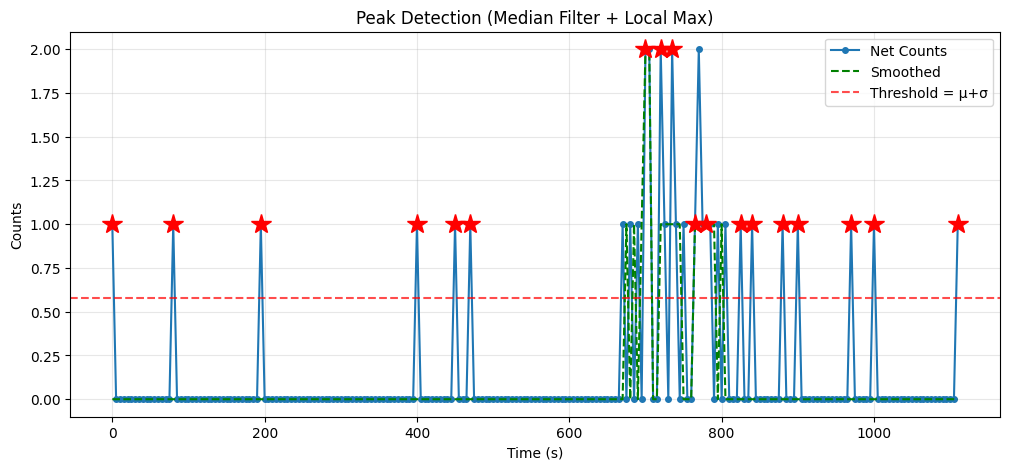

In [ ]:
# 步骤 1：中值滤波去噪
from scipy.signal import medfilt
from scipy.ndimage import maximum_filter

smoothed = medfilt(net_counts, kernel_size=3)

# 步骤 2：局部最大值
local_max = maximum_filter(smoothed, size=5)
peaks = np.where(smoothed == local_max)[0]

# 步骤 3：按高度过滤（只保留 > 背景+1σ 的峰）
threshold = np.mean(net_counts) + np.std(net_counts)
peaks = peaks[net_counts[peaks] > threshold]

# 步骤 4：合并太接近的峰（<5个bin认为是一个峰）
peaks_filtered = [peaks[0]]
for p in peaks[1:]:
    if p - peaks_filtered[-1] > 2:  # 最少间隔2个bin
        peaks_filtered.append(p)
peaks = np.array(peaks_filtered)

print(f"找到 {len(peaks)} 个峰：")
for i, p in enumerate(peaks):
    print(f"  峰{i+1}：时间={times[p]:.1f}s，强度={net_counts[p]:.2f}")

# 可视化
plt.figure(figsize=(12, 5))
plt.plot(times, net_counts, 'o-', label='Net Counts', markersize=4)
plt.plot(times, smoothed, 'g--', label='Smoothed', linewidth=1.5)
plt.axhline(threshold, color='r', linestyle='--', label=f'Threshold = μ+σ', alpha=0.7)
for p in peaks:
    plt.plot(times[p], net_counts[p], 'r*', markersize=15)
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Peak Detection (Median Filter + Local Max)')
plt.show()

将对检测到的 18 个峰进行高斯拟合 (带参数约束)...

[[Model]]
    ((((((((((((((((((Model(constant) + Model(gaussian, prefix='g0_')) + Model(gaussian, prefix='g1_')) + Model(gaussian, prefix='g2_')) + Model(gaussian, prefix='g3_')) + Model(gaussian, prefix='g4_')) + Model(gaussian, prefix='g5_')) + Model(gaussian, prefix='g6_')) + Model(gaussian, prefix='g7_')) + Model(gaussian, prefix='g8_')) + Model(gaussian, prefix='g9_')) + Model(gaussian, prefix='g10_')) + Model(gaussian, prefix='g11_')) + Model(gaussian, prefix='g12_')) + Model(gaussian, prefix='g13_')) + Model(gaussian, prefix='g14_')) + Model(gaussian, prefix='g15_')) + Model(gaussian, prefix='g16_')) + Model(gaussian, prefix='g17_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 112000
    # data points      = 223
    # variables        = 55
    chi-square         = 25.8679829
    reduced chi-square = 0.15397609
    Akaike info crit   = -370.378962
    Bayesian info crit = -182.984515
    R-squared          = 0.34522

将对检测到的 18 个峰进行高斯拟合 (带参数约束)...

[[Model]]
    ((((((((((((((((((Model(constant) + Model(gaussian, prefix='g0_')) + Model(gaussian, prefix='g1_')) + Model(gaussian, prefix='g2_')) + Model(gaussian, prefix='g3_')) + Model(gaussian, prefix='g4_')) + Model(gaussian, prefix='g5_')) + Model(gaussian, prefix='g6_')) + Model(gaussian, prefix='g7_')) + Model(gaussian, prefix='g8_')) + Model(gaussian, prefix='g9_')) + Model(gaussian, prefix='g10_')) + Model(gaussian, prefix='g11_')) + Model(gaussian, prefix='g12_')) + Model(gaussian, prefix='g13_')) + Model(gaussian, prefix='g14_')) + Model(gaussian, prefix='g15_')) + Model(gaussian, prefix='g16_')) + Model(gaussian, prefix='g17_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 112000
    # data points      = 223
    # variables        = 55
    chi-square         = 25.8679829
    reduced chi-square = 0.15397609
    Akaike info crit   = -370.378962
    Bayesian info crit = -182.984515
    R-squared          = 0.34522

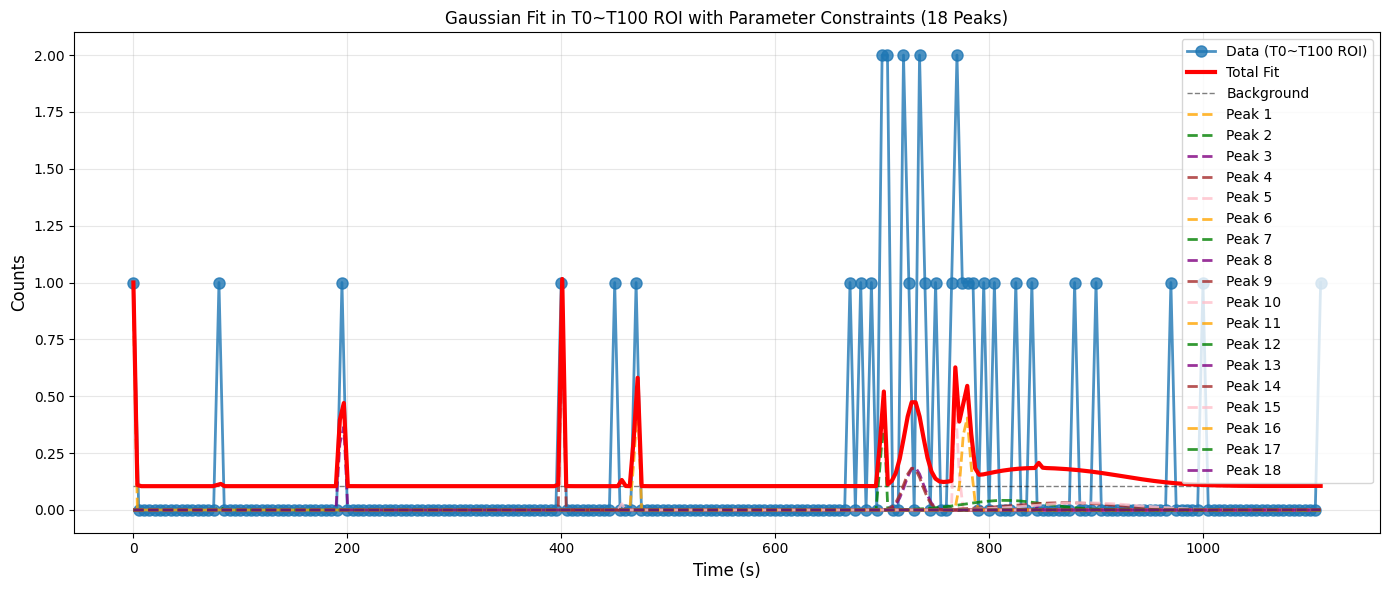


拟合质量指标
卡方:                 25.8680
约化卡方 (χ²/dof):      0.1540
AIC (赤池信息准则):       -370.379
BIC (贝叶斯信息准则):     -182.985
R-squared:            0.3452


In [ ]:
## 在 T0~T100 ROI 范围内进行高斯拟合（带参数约束）

from lmfit.models import GaussianModel, ConstantModel

# 检查是否有峰值
if len(peaks) == 0:
    print("没有检测到峰值，无法拟合")
else:
    print(f"将对检测到的 {len(peaks)} 个峰进行高斯拟合 (带参数约束)...\n")
    
    # 构建多峰模型
    model = ConstantModel()
    for i in range(len(peaks)):
        model = model + GaussianModel(prefix=f'g{i}_')
    
    # 设置参数初值和边界
    params = model.make_params()
    
    # 背景参数
    params['c'].value = np.mean(net_counts[0:2])  # 前两个点的平均值
    params['c'].min = 0.0
    params['c'].max = np.max(net_counts)
    
    # 每个峰的参数
    for i, peak_idx in enumerate(peaks):
        # 中心位置：限制在数据的近邻范围内
        params[f'g{i}_center'].value = times[peak_idx]
        params[f'g{i}_center'].min = times[peak_idx] - 10
        params[f'g{i}_center'].max = times[peak_idx] + 10
        
        # 幅度：限制为正
        params[f'g{i}_amplitude'].value = net_counts[peak_idx] - np.mean(net_counts)
        params[f'g{i}_amplitude'].min = 0.1  # 必须为正
        params[f'g{i}_amplitude'].max = 2 * np.max(net_counts)
        
        # 宽度：合理的秒级范围
        params[f'g{i}_sigma'].value = 8.0  # 较宽的初值
        params[f'g{i}_sigma'].min = 1.0
        params[f'g{i}_sigma'].max = 50.0
    
    # 执行拟合
    try:
        result = model.fit(net_counts, params, x=times, method='leastsq')
        
        print(result.fit_report())
        print("\n" + "="*70)
        print("T0~T100 ROI 范围内的拟合峰值属性")
        print("="*70)
        
        for i in range(len(peaks)):
            center = result.params[f'g{i}_center'].value
            amp = result.params[f'g{i}_amplitude'].value
            sigma = result.params[f'g{i}_sigma'].value
            fwhm = 2.355 * sigma
            
            # 获取误差
            center_err = result.params[f'g{i}_center'].stderr or 0
            amp_err = result.params[f'g{i}_amplitude'].stderr or 0
            sigma_err = result.params[f'g{i}_sigma'].stderr or 0
            fwhm_err = 2.355 * sigma_err
            
            print(f"\n峰 {i+1}:")
            print(f"  中心时间: {center:.3f} ± {center_err:.3f} s  (范围: [{times[peak_idx]-10:.1f}, {times[peak_idx]+10:.1f}] s)")
            print(f"  幅度:     {amp:.4f} ± {amp_err:.4f}")
            print(f"  σ (宽度): {sigma:.3f} ± {sigma_err:.3f} s")
            print(f"  FWHM:     {fwhm:.3f} ± {fwhm_err:.3f} s")
        
        # 绘制拟合结果
        plt.figure(figsize=(14, 6))
        x_fine = np.linspace(times[0], times[-1], 300)
        
        # 数据和总拟合
        plt.plot(times, net_counts, 'o-', label='Data (T0~T100 ROI)', 
                markersize=8, alpha=0.8, linewidth=2)
        plt.plot(x_fine, result.eval(x=x_fine), 'r-', linewidth=3, label='Total Fit', zorder=5)
        
        # 背景
        background = result.params['c'].value * np.ones_like(x_fine)
        plt.plot(x_fine, background, 'k--', linewidth=1, label='Background', alpha=0.5)
        
        # 各个高斯分量
        colors = ['orange', 'green', 'purple', 'brown', 'pink']
        for i in range(len(peaks)):
            comp = GaussianModel(prefix=f'g{i}_')
            plt.plot(x_fine, comp.eval(result.params, x=x_fine), '--', 
                    linewidth=2, label=f'Peak {i+1}', color=colors[i % len(colors)], alpha=0.8)
        
        plt.xlabel('Time (s)', fontsize=12)
        plt.ylabel('Counts', fontsize=12)
        plt.legend(loc='best', fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.title(f'Gaussian Fit in T0~T100 ROI with Parameter Constraints ({len(peaks)} Peak{"s" if len(peaks) > 1 else ""})', fontsize=12)
        plt.tight_layout()
        plt.show()
        
        # 显示拟合质量指标
        print(f"\n" + "="*70)
        print("拟合质量指标")
        print("="*70)
        print(f"卡方:                 {result.chisqr:.4f}")
        print(f"约化卡方 (χ²/dof):      {result.redchi:.4f}")
        print(f"AIC (赤池信息准则):       {result.aic:.3f}")
        print(f"BIC (贝叶斯信息准则):     {result.bic:.3f}")
        print(f"R-squared:            {1 - result.residual.std()**2 / net_counts.var():.4f}")
        
    except Exception as e:
        print(f"拟合失败: {e}")
        import traceback
        traceback.print_exc()

lc 点数: 7
lc 时间范围: [354.00, 969.50] s
T0~T100 (relative): [677.07, 803.58] s
ROI 点数: 4
在 lc-ROI 中找到 0 个峰：


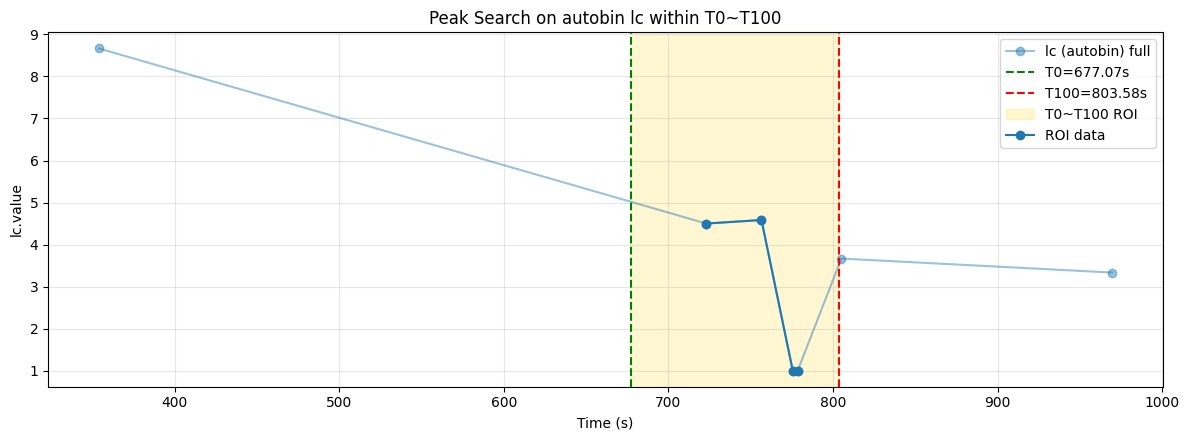

已更新 peaks/times/net_counts 为 lc-ROI 数据


In [ ]:
## 在 T0 ~ T100 范围内重新进行峰搜索

# 获取T0和T100时间范围
t0 = res['t100_tstart']      # T0（突发开始）
t100 = res['t100_tstop']      # T100（突发结束，90%能量）

print(f"从 res 字典获得的:")
print(f"  T0 ~ T100 时间范围：[{t0:.2f}, {t100:.2f}] s")
print(f"  持续时间：{t100 - t0:.2f} s")

# 从原始 srclc 中重新提取原始数据（未被修改）
times_full = srclc.time.copy()
net_counts_full = srclc.value.copy()

print(f"\n从 srclc 获得的数据:")
print(f"  时间范围：[{times_full.min():.2f}, {times_full.max():.2f}] s")
print(f"  数据点数：{len(times_full)}")

# 关键：检查参考时间
print(f"\n参考时间检查:")
print(f"  srclc.timezero = {srclc.timezero}")
print(f"  src.timezero = {src.timezero}")

# 时间转换：res中的时间是相对于 timezero 吗？
# 如果 res 中的时间是绝对时间，而 srclc.time 是相对时间，需要调整
# 检查一下第一个和最后一个时间点
print(f"\nres 中记录的和 srclc 中的时间对比:")
print(f"  res['bb_edges_time'][0] = {res['bb_edges_time'][0]}")
print(f"  srclc.time[0] = {times_full[0]}")

# 如果存在偏移，计算一下
time_offset = res['bb_edges_time'][0] - times_full[0]
print(f"  可能的时间偏移 = {time_offset:.2f}")

# 使用相对后时间进行重新映射
t0_rel = t0 - time_offset
t100_rel = t100 - time_offset

print(f"\n转换后的时间范围 (相对)：[{t0_rel:.2f}, {t100_rel:.2f}] s")

# 在时间范围内提取数据（使用转换后的时间）
mask = (times_full >= t0_rel) & (times_full <= t100_rel)
times_roi = times_full[mask]           # 兴趣区域 (ROI) 时间
net_counts_roi = net_counts_full[mask]  # 兴趣区域计数

print(f"\n兴趣区域包含 {len(times_roi)} 个 bin")
if len(times_roi) > 0:
    print(f"时间范围：[{times_roi[0]:.2f}, {times_roi[-1]:.2f}] s")
    
    # 步骤 1：中值滤波去噪
    from scipy.signal import medfilt
    from scipy.ndimage import maximum_filter
    
    smoothed_roi = medfilt(net_counts_roi, kernel_size=3)
    
    # 步骤 2：局部最大值
    local_max_roi = maximum_filter(smoothed_roi, size=5)
    peaks_roi_idx = np.where(smoothed_roi == local_max_roi)[0]
    
    # 步骤 3：按高度过滤（只保留 > 背景+1σ 的峰）
    threshold_roi = np.mean(net_counts_roi) + np.std(net_counts_roi)
    peaks_roi_idx = peaks_roi_idx[net_counts_roi[peaks_roi_idx] > threshold_roi]
    
    # 步骤 4：合并太接近的峰
    if len(peaks_roi_idx) > 0:
        peaks_filtered_roi = [peaks_roi_idx[0]]
        for p in peaks_roi_idx[1:]:
            if p - peaks_filtered_roi[-1] > 2:  # 最少间隔2个bin
                peaks_filtered_roi.append(p)
        peaks_roi_idx = np.array(peaks_filtered_roi)
    else:
        peaks_roi_idx = np.array([])
    
    print(f"\n在 T0~T100 (ROI) 范围内找到 {len(peaks_roi_idx)} 个峰：")
    for i, idx in enumerate(peaks_roi_idx):
        print(f"  峰{i+1}：时间={times_roi[idx]:.2f}s，强度={net_counts_roi[idx]:.2f}")
    
    # 可视化：全时间范围 vs 兴趣区域
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # 上图：全时间范围，标记 T0~T100
    ax1.plot(times_full, net_counts_full, 'o-', label='Full Light Curve', markersize=3, alpha=0.7)
    ax1.axvline(t0_rel, color='green', linestyle='--', linewidth=2, label=f'T0 = {t0_rel:.2f}s')
    ax1.axvline(t100_rel, color='red', linestyle='--', linewidth=2, label=f'T100 = {t100_rel:.2f}s')
    ax1.fill_between([t0_rel, t100_rel], ax1.get_ylim()[0], ax1.get_ylim()[1], 
                      alpha=0.2, color='yellow', label='T0~T100 ROI')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Counts')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.set_title('Full Time Range with T0~T100 Region')
    
    # 下图：T0~T100放大图，显示峰值
    ax2.plot(times_roi, net_counts_roi, 'o-', label='Data (ROI)', markersize=5, alpha=0.8)
    ax2.plot(times_roi, smoothed_roi, 'g--', label='Smoothed', linewidth=1.5)
    ax2.axhline(threshold_roi, color='r', linestyle='--', 
                label=f'Threshold = μ+σ = {threshold_roi:.2f}', alpha=0.7)
    for idx in peaks_roi_idx:
        ax2.plot(times_roi[idx], net_counts_roi[idx], 'r*', markersize=15)
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Counts')
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    ax2.set_title(f'Zoomed T0~T100 Range: {len(peaks_roi_idx)} Peaks Found')
    
    plt.tight_layout()
    plt.show()
    
    # 保存 ROI 数据供下面的拟合使用
    peaks = peaks_roi_idx
    times = times_roi
    net_counts = net_counts_roi
    print(f"\n已更新 peaks, times, net_counts (ROI) 用于后续高斯拟合")
else:
    print("ERROR: 没有找到匹配的 ROI 数据，请检查时间坐标系")